# Analyse de l'Économie de l'Inde

## Préparation des données

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_eco=pd.read_csv('Global Economy Indicators.csv')
df_eco.head()

,CountryID,Country,Year,AMA exchange rate,IMF based exchange rate,Population,Currency,Per capita GNI,"Agriculture, hunting, forestry, fishing (ISIC A-B)",Changes in inventories,...,Household consumption expenditure (including Non-profit institutions serving households),Imports of goods and services,Manufacturing (ISIC D),"Mining, Manufacturing, Utilities (ISIC C-E)",Other Activities (ISIC J-P),Total Value Added,"Transport, storage and communication (ISIC I)","Wholesale, retail trade, restaurants and hotels (ISIC G-H)",Gross National Income(GNI) in USD,Gross Domestic Product (GDP)
0,4,Afghanistan,1970,0.044998,0.044998,10752971,Afghani,164,8.699174e+08,NaN,...,1.551094e+09,195277226.0,370146827.0,376690811.0,127747843.0,1.731454e+09,83917200.0,226387091.0,1.766528e+09,1.731436e+09
1,4,Afghanistan,1971,0.044998,0.044998,11015857,Afghani,168,9.108281e+08,NaN,...,1.675426e+09,276296480.0,387549502.0,394401164.0,133754097.0,1.812857e+09,87860382.0,237019196.0,1.850122e+09,1.812838e+09
2,4,Afghanistan,1972,0.044998,0.044998,11286753,Afghani,149,8.279453e+08,NaN,...,1.498812e+09,290370350.0,352284669.0,358512865.0,121582672.0,1.647918e+09,79864525.0,215477287.0,1.683948e+09,1.647900e+09
3,4,Afghanistan,1973,0.044998,0.044998,11575305,Afghani,150,8.554869e+08,NaN,...,1.508024e+09,262962880.0,364010279.0,370445793.0,125630236.0,1.702735e+09,82528885.0,222624293.0,1.739998e+09,1.702716e+09
4,4,Afghanistan,1974,0.044998,0.044998,11869879,Afghani,177,1.035913e+09,NaN,...,1.778819e+09,305679151.0,440760406.0,448552790.0,152119162.0,2.061752e+09,99918604.0,269525910.0,2.106420e+09,2.061729e+09


In [4]:
# Indicateurs de Change et Monnaie
indicateurs_change_monnaie = [
    ' AMA exchange rate ',
    ' IMF based exchange rate ',
    ' Currency '
]

# Indicateurs Démographiques
indicateurs_demographiques = [
    ' Population '
]

# Indicateurs de Revenu et Production
indicateurs_revenu_production = [
    ' Per capita GNI ',
    ' Gross National Income(GNI) in USD ',
    ' Gross Domestic Product (GDP) '
]

# Composantes du PIB
composantes_pib = [
    ' Exports of goods and services ',
    ' Imports of goods and services ',
    ' Final consumption expenditure ',
    ' Household consumption expenditure (including Non-profit institutions serving households) ',
    ' General government final consumption expenditure ',
    ' Gross capital formation ',
    ' Gross fixed capital formation (including Acquisitions less disposals of valuables) ',
    ' Changes in inventories '
]

# Secteurs Économiques
secteurs_economiques = [
    ' Agriculture, hunting, forestry, fishing (ISIC A-B) ',
    ' Mining, Manufacturing, Utilities (ISIC C-E) ',
    ' Manufacturing (ISIC D) ',
    ' Construction (ISIC F) ',
    ' Wholesale, retail trade, restaurants and hotels (ISIC G-H) ',
    ' Transport, storage and communication (ISIC I) ',
    ' Other Activities (ISIC J-P) ',
    ' Total Value Added '
]

# Affichage des listes
print("Indicateurs de Change et Monnaie:", indicateurs_change_monnaie)
print("Indicateurs Démographiques:", indicateurs_demographiques)
print("Indicateurs de Revenu et Production:", indicateurs_revenu_production)
print("Composantes du PIB:", composantes_pib)
print("Secteurs Économiques:", secteurs_economiques)

Indicateurs de Change et Monnaie: [' AMA exchange rate ', ' IMF based exchange rate ', ' Currency ']
Indicateurs Démographiques: [' Population ']
Indicateurs de Revenu et Production: [' Per capita GNI ', ' Gross National Income(GNI) in USD ', ' Gross Domestic Product (GDP) ']
Composantes du PIB: [' Exports of goods and services ', ' Imports of goods and services ', ' Final consumption expenditure ', ' Household consumption expenditure (including Non-profit institutions serving households) ', ' General government final consumption expenditure ', ' Gross capital formation ', ' Gross fixed capital formation (including Acquisitions less disposals of valuables) ', ' Changes in inventories ']
Secteurs Économiques: [' Agriculture, hunting, forestry, fishing (ISIC A-B) ', ' Mining, Manufacturing, Utilities (ISIC C-E) ', ' Manufacturing (ISIC D) ', ' Construction (ISIC F) ', ' Wholesale, retail trade, restaurants and hotels (ISIC G-H) ', ' Transport, storage and communication (ISIC I) ', ' Othe

In [24]:
# Dictionnaire de traduction des termes économiques
traduction = {
    ' AMA exchange rate ': 'Taux de change AMA',
    ' IMF based exchange rate ': 'Taux de change basé sur le FMI',
    ' Population ': 'Population',
    ' Currency ': 'Monnaie',
    ' Per capita GNI ': 'Revenu National Brut par habitant',
    ' Agriculture, hunting, forestry, fishing (ISIC A-B) ': 'Agriculture, chasse, sylviculture, pêche (ISIC A-B)',
    ' Changes in inventories ': 'Variations des stocks',
    ' Construction (ISIC F) ': 'Construction (ISIC F)',
    ' Exports of goods and services ': 'Exportations de biens et services',
    ' Final consumption expenditure ': 'Dépenses de consommation finale',
    ' General government final consumption expenditure ': 'Dépenses de consommation finale des administrations publiques',
    ' Gross capital formation ': 'Formation brute de capital',
    ' Gross fixed capital formation (including Acquisitions less disposals of valuables) ': 'Formation brute de capital fixe (y compris les acquisitions moins les cessions de valeurs)',
    ' Household consumption expenditure (including Non-profit institutions serving households) ': 'Dépenses de consommation des ménages (y compris les institutions sans but lucratif au service des ménages)',
    ' Imports of goods and services ': 'Importations de biens et services',
    ' Manufacturing (ISIC D) ': 'Fabrication (ISIC D)',
    ' Mining, Manufacturing, Utilities (ISIC C-E) ': 'Mines, manufactures, services publics (ISIC C-E)',
    ' Other Activities (ISIC J-P) ': 'Autres activités (ISIC J-P)',
    ' Total Value Added ': 'Valeur ajoutée totale',
    ' Transport, storage and communication (ISIC I) ': 'Transport, entreposage et communication (ISIC I)',
    ' Wholesale, retail trade, restaurants and hotels (ISIC G-H) ': 'Commerce de gros, commerce de détail, restaurants et hôtels (ISIC G-H)',
    ' Gross National Income(GNI) in USD ': 'Revenu National Brut (RNB) en USD',
    ' Gross Domestic Product (GDP) ': 'Produit Intérieur Brut (PIB)'
}


In [5]:
pd.options.mode.chained_assignment = None

In [7]:
df_eco_inde=df_eco[df_eco[' Country ']==' India ']
df_eco_inde.drop(' Country ',axis=1,inplace=True)
df_eco_inde.drop(' CountryID ',axis=1,inplace=True)
df_eco_inde.head()

,Year,AMA exchange rate,IMF based exchange rate,Population,Currency,Per capita GNI,"Agriculture, hunting, forestry, fishing (ISIC A-B)",Changes in inventories,Construction (ISIC F),Exports of goods and services,...,Household consumption expenditure (including Non-profit institutions serving households),Imports of goods and services,Manufacturing (ISIC D),"Mining, Manufacturing, Utilities (ISIC C-E)",Other Activities (ISIC J-P),Total Value Added,"Transport, storage and communication (ISIC I)","Wholesale, retail trade, restaurants and hotels (ISIC G-H)",Gross National Income(GNI) in USD,Gross Domestic Product (GDP)
4161,1970,7.500000,7.500000,557501301,Indian Rupee,111,2.515959e+10,5.297168e+08,2.799197e+09,2.361333e+09,...,4.974115e+10,2.421333e+09,8.714053e+09,1.014891e+10,1.430824e+10,5.757035e+10,2.056084e+09,3.098333e+09,6.204382e+10,6.242248e+10
4162,1971,7.491935,7.491935,569999178,Indian Rupee,117,2.572868e+10,4.917677e+08,3.082144e+09,2.453305e+09,...,5.370584e+10,2.677546e+09,9.678522e+09,1.121643e+10,1.578590e+10,6.140620e+10,2.223388e+09,3.369648e+09,6.651007e+10,6.689848e+10
4163,1972,7.594468,7.594468,582837973,Indian Rupee,124,2.791765e+10,-8.558552e+08,3.313854e+09,2.929764e+09,...,5.839389e+10,2.698016e+09,1.060872e+10,1.224729e+10,1.703519e+10,6.659607e+10,2.405443e+09,3.676637e+09,7.234652e+10,7.274418e+10
4164,1973,7.742039,7.742039,596107483,Indian Rupee,145,3.608735e+10,2.469715e+09,3.350710e+09,3.655368e+09,...,6.905254e+10,4.102279e+09,1.259287e+10,1.437317e+10,1.869853e+10,7.959578e+10,2.615896e+09,4.470111e+09,8.643157e+10,8.685136e+10
4165,1974,8.101603,8.101603,609721951,Indian Rupee,160,3.778134e+10,2.282050e+09,3.507331e+09,4.733631e+09,...,7.994797e+10,5.898832e+09,1.546509e+10,1.776778e+10,2.098190e+10,8.894320e+10,3.157697e+09,5.747151e+09,9.761880e+10,9.797799e+10


In [8]:
del df_eco

## Indicateurs du Pib

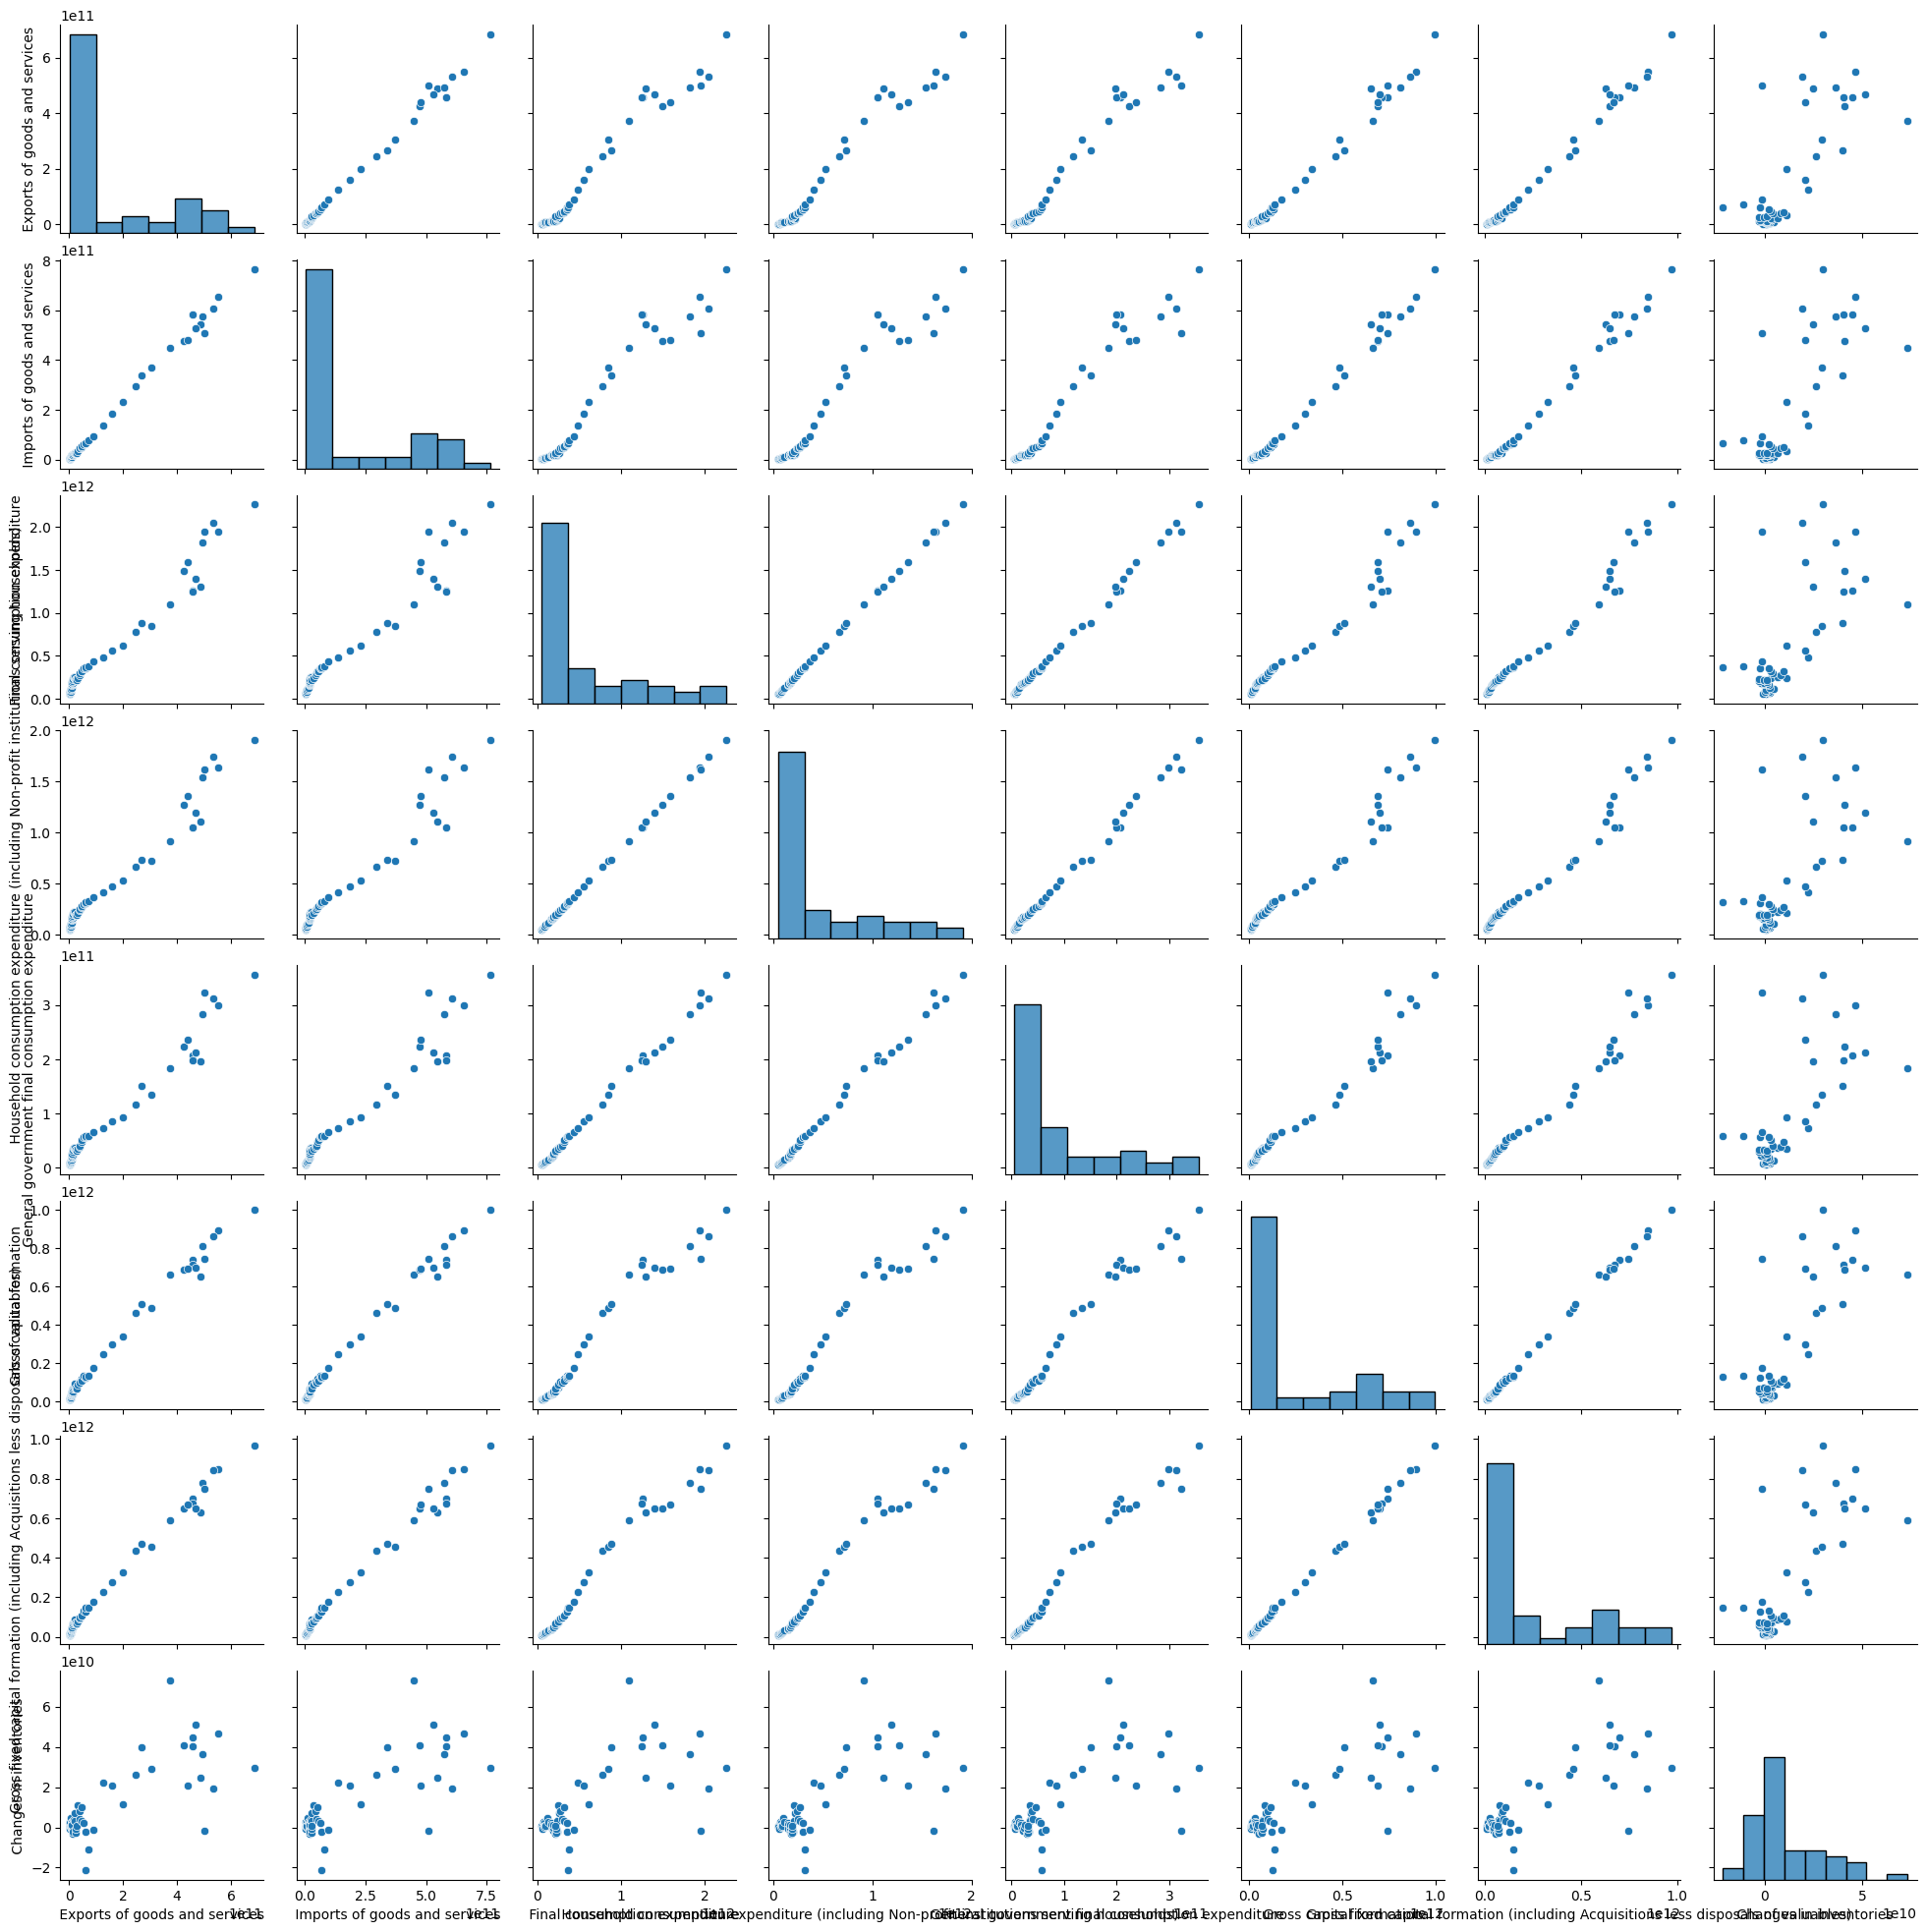

In [10]:
sns.pairplot(df_eco_inde[composantes_pib])

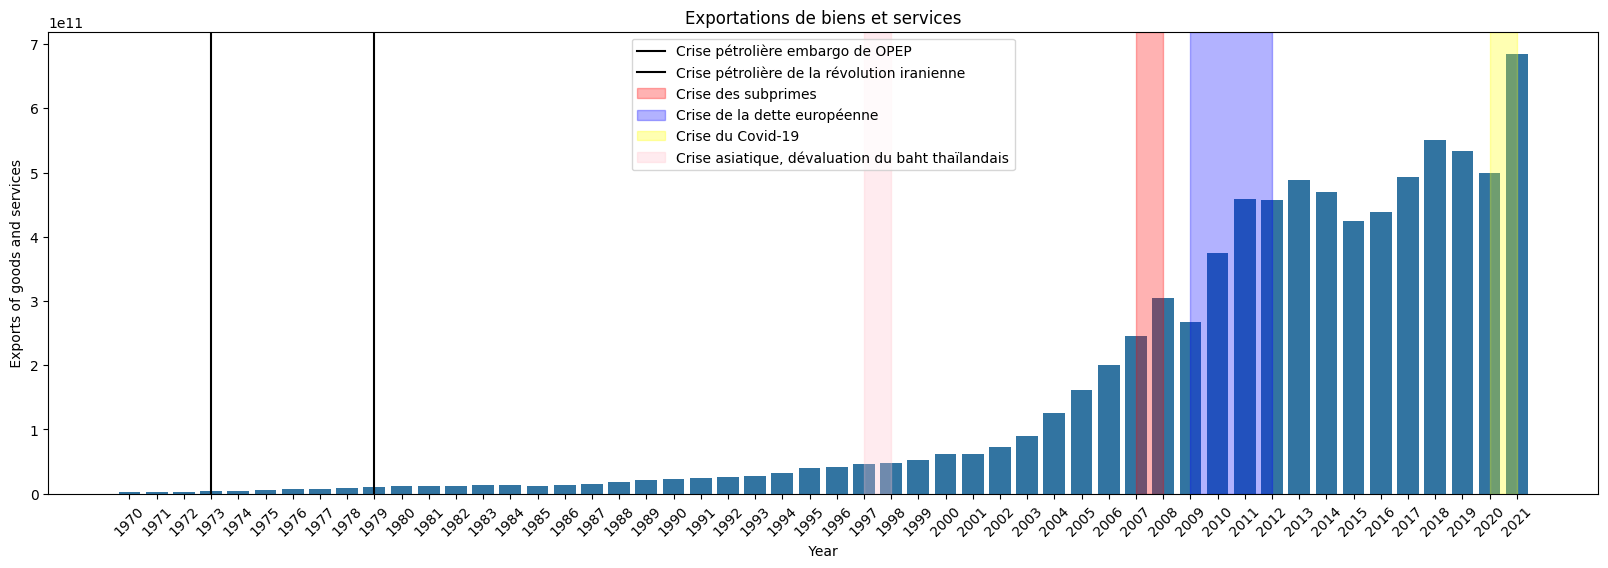

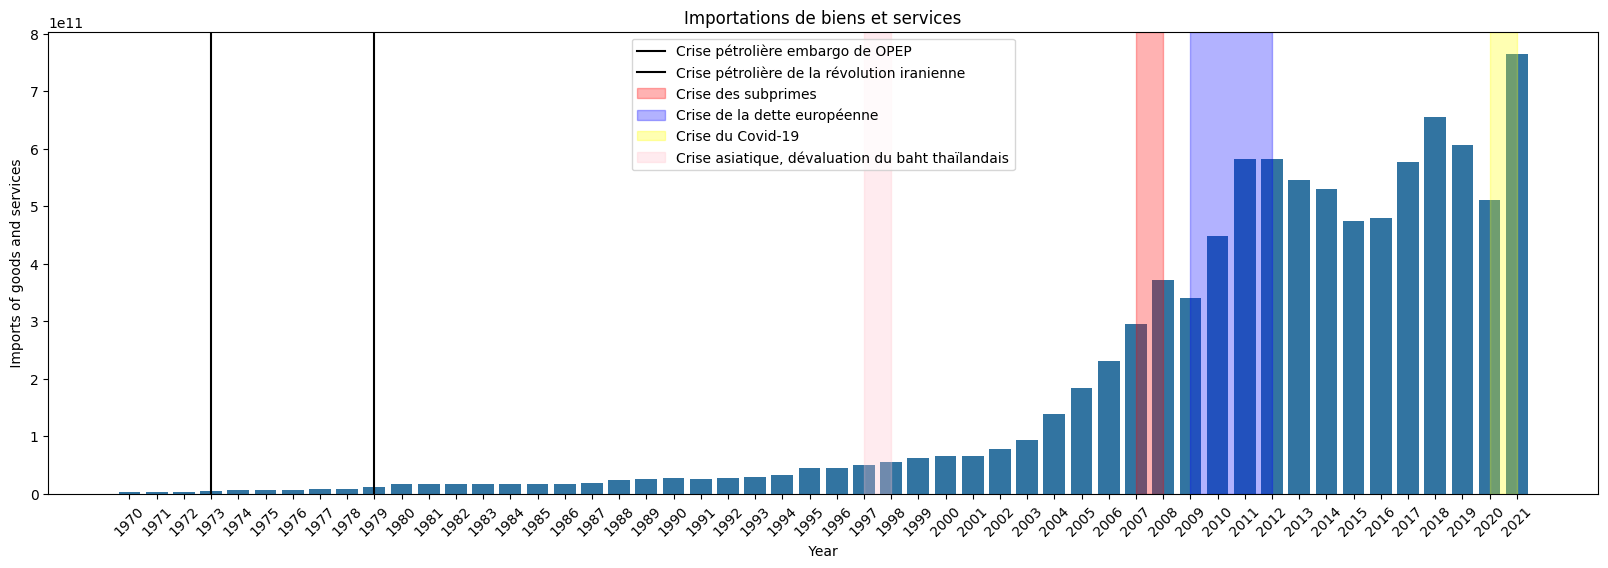

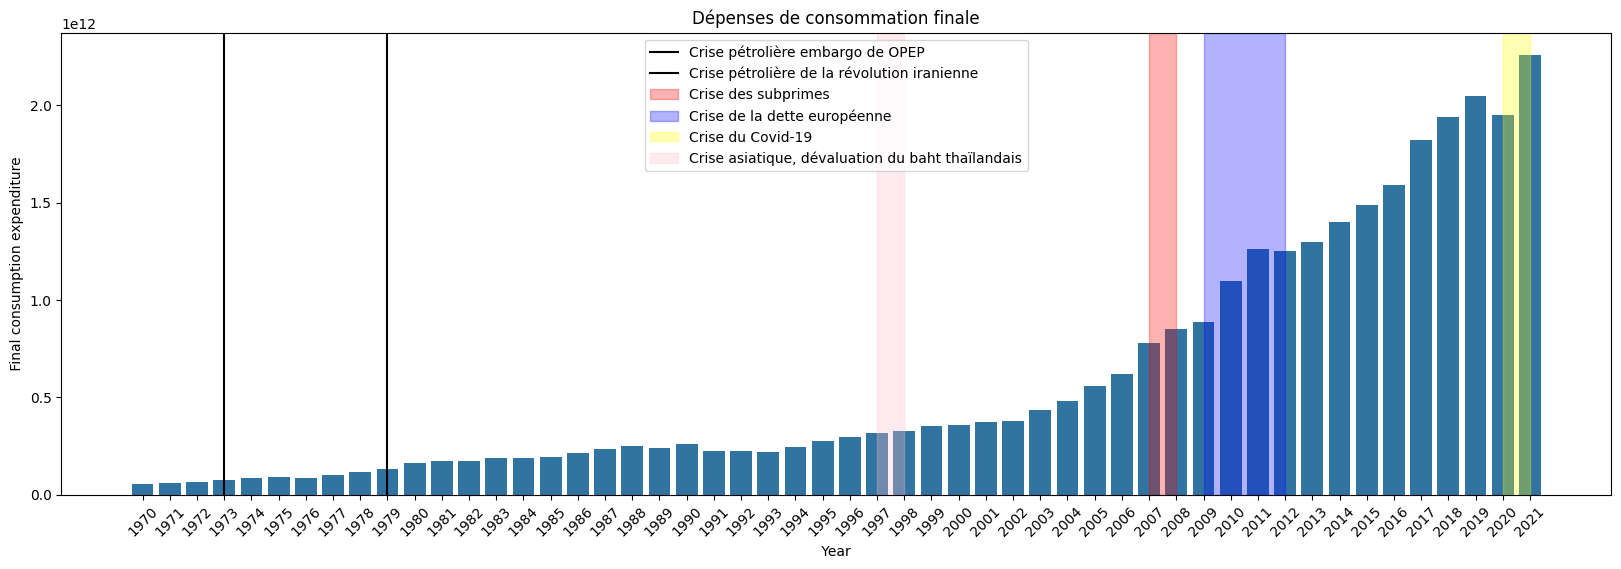

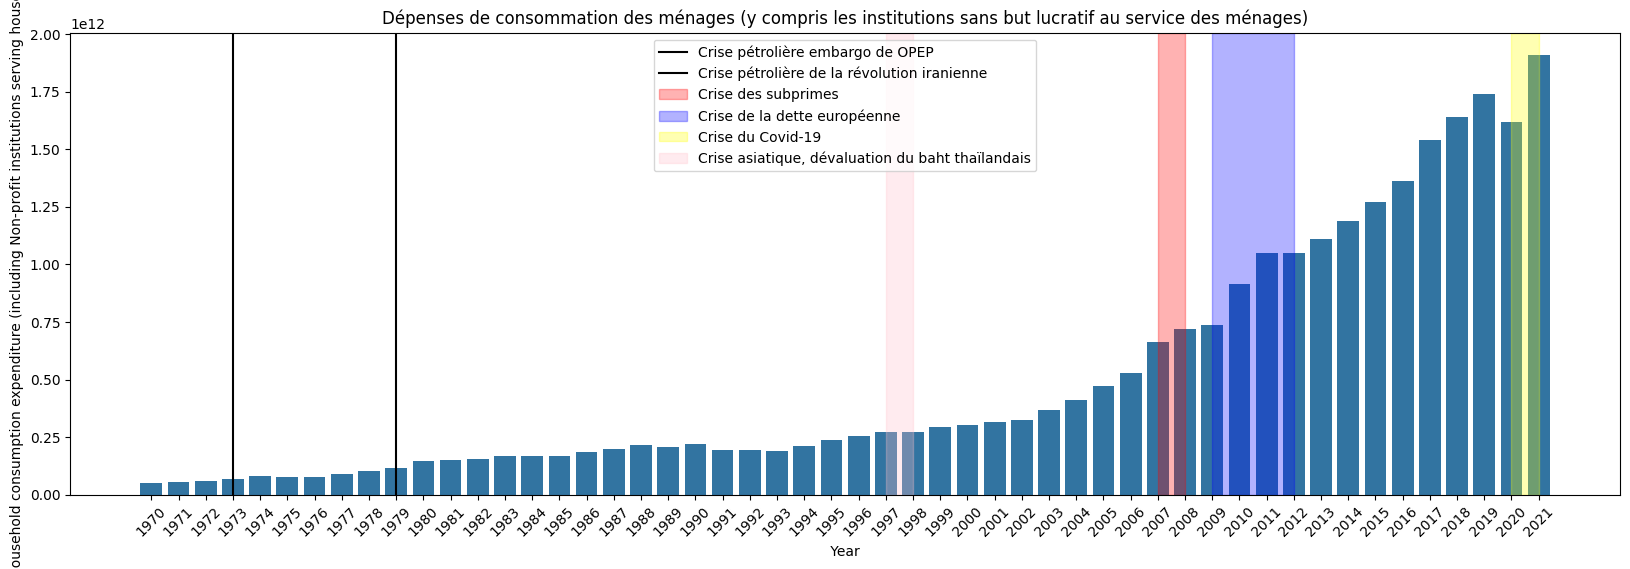

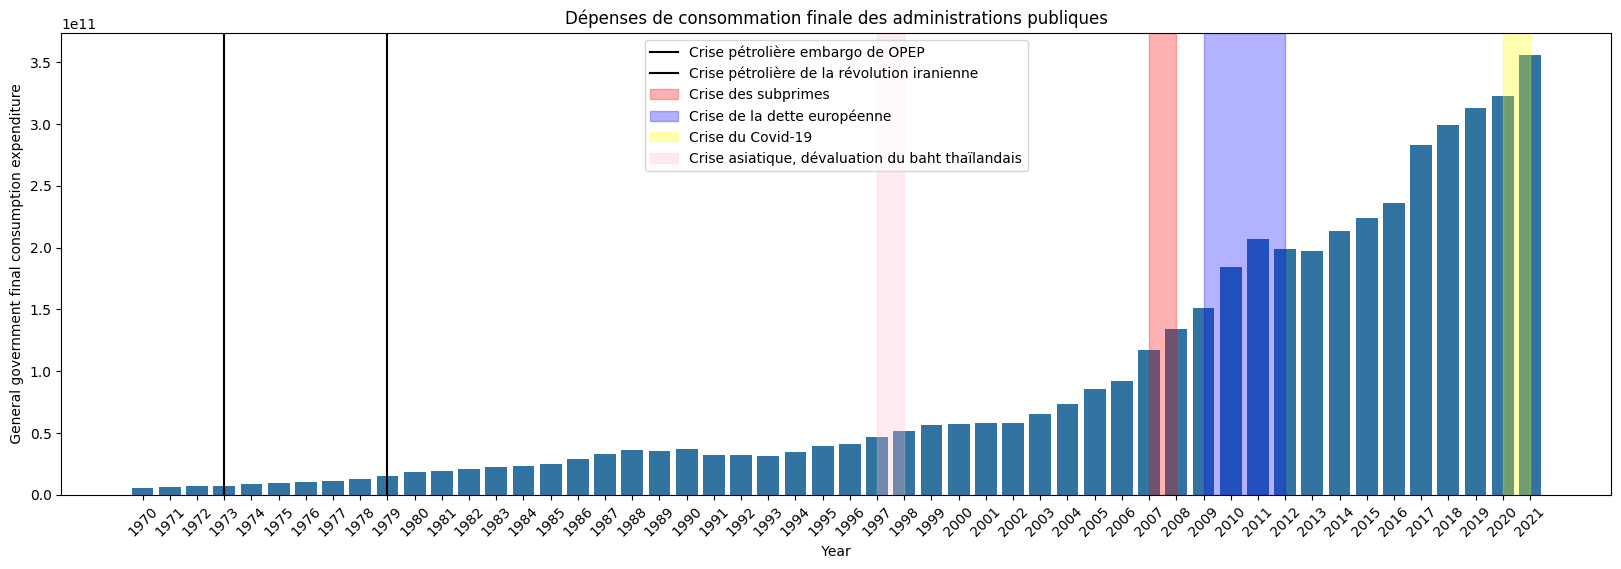

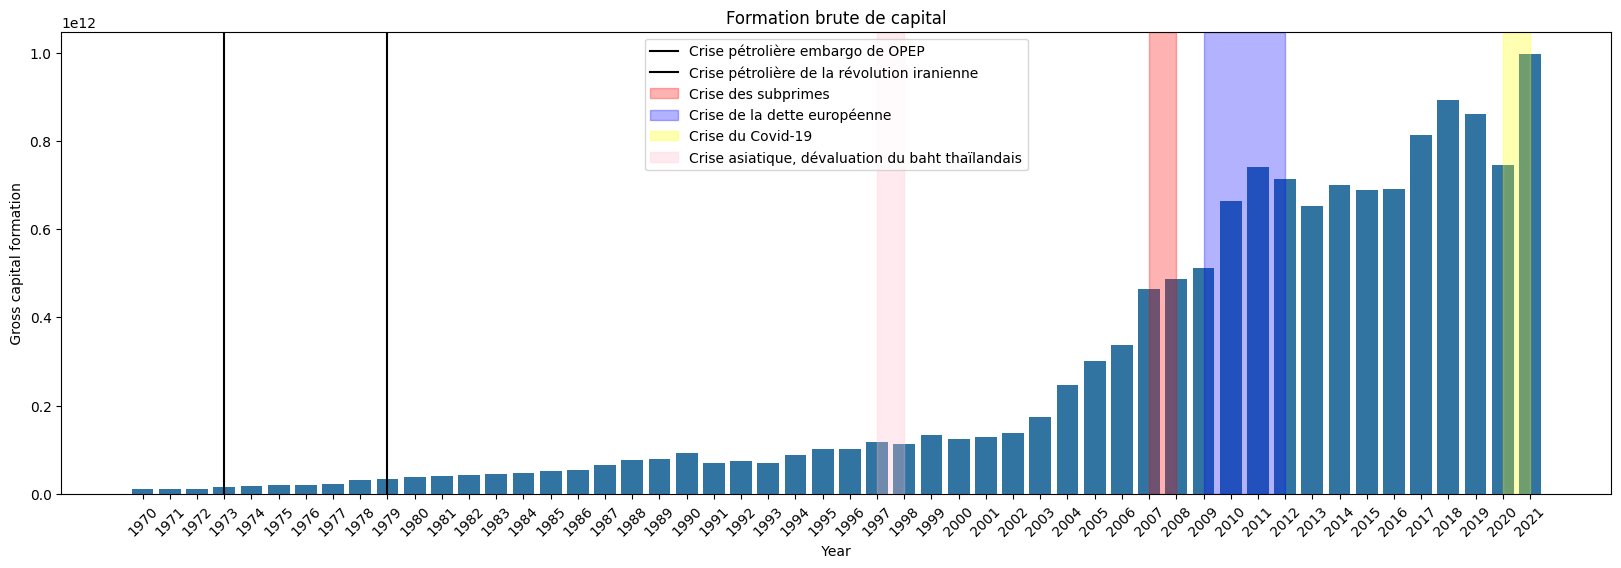

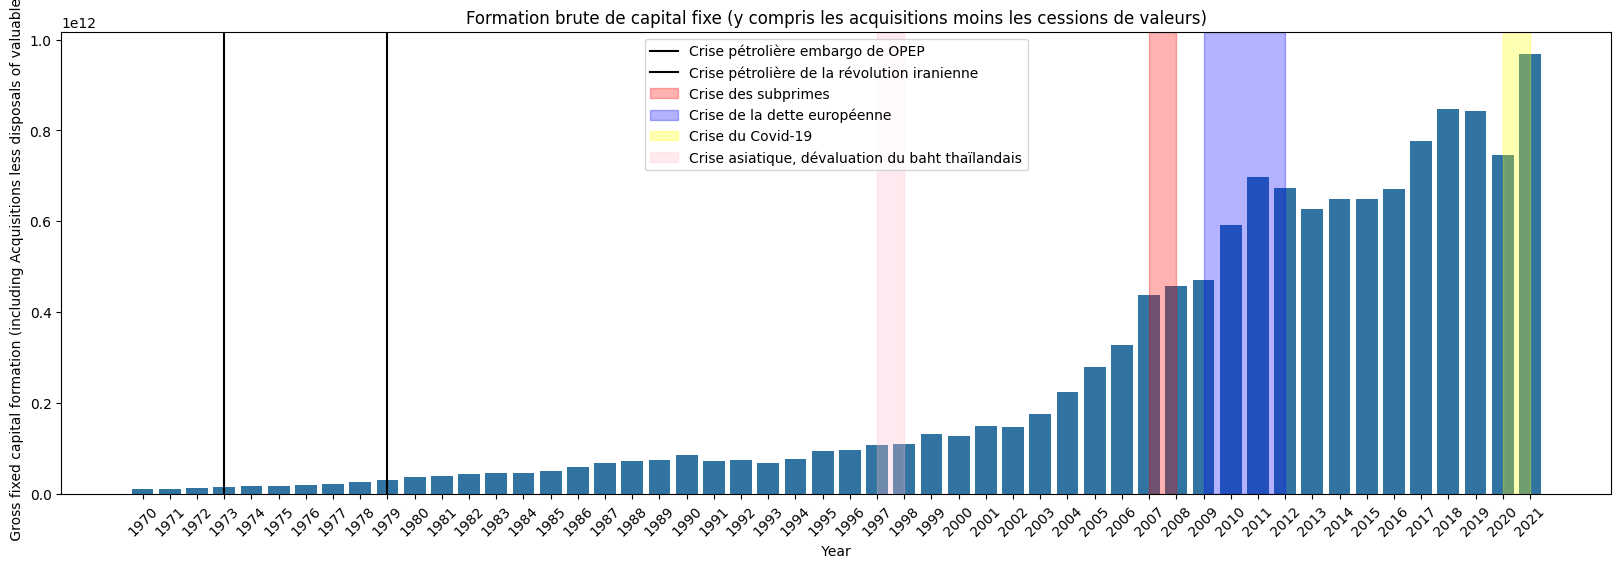

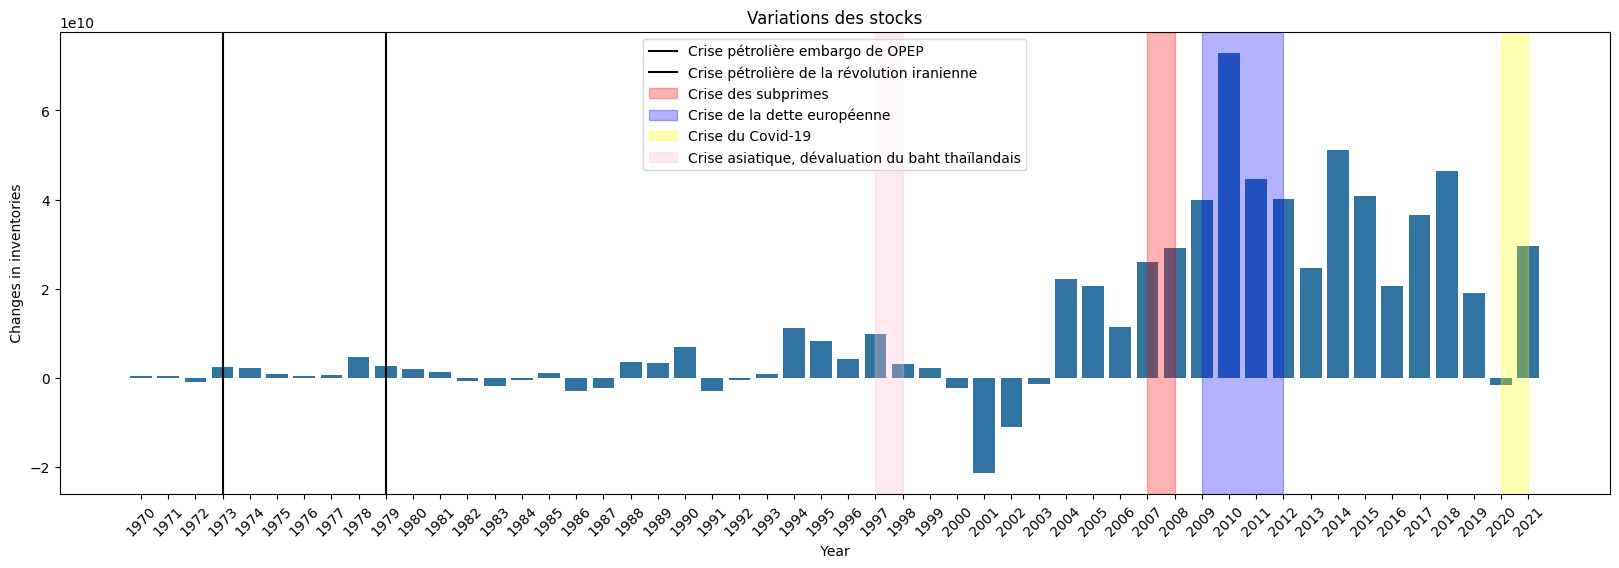

In [27]:
Year=df_eco_inde[' Year '].tolist() 

#On commence par lister les crises pour les faire apparaître sur notre barplot
petrole_OPEP=Year.index(1973)

petrole_iran=Year.index(1979)

asiatic_crisis_d=Year.index(1997)
asiatic_crisis_f=Year.index(1998)

subprime_d=Year.index(2007)
subprime_f=Year.index(2008)

dette_européenne_d=Year.index(2009)
dette_européenne_f=Year.index(2012)

covid_d=Year.index(2020)
covid_f=Year.index(2021)

for elem in composantes_pib:
    plt.figure(figsize=(20,6))
    sns.barplot(x=df_eco_inde[' Year '], y=df_eco_inde[elem])
    #plt.axvline(x=subprime_d, color='red', linestyle='-', label='début de la Crise des subprimes')
    #plt.axvline(x=subprime_f, color='red', linestyle='-', label='fin de la Crise des subprimes')
    plt.axvline(x=petrole_OPEP, color='black', linestyle='-', label='Crise pétrolière embargo de OPEP')
    plt.axvline(x=petrole_iran, color='black', linestyle='-', label='Crise pétrolière de la révolution iranienne')
    plt.axvspan(subprime_d, subprime_f, color='red',alpha=0.3,  label='Crise des subprimes')
    plt.axvspan(dette_européenne_d, dette_européenne_f, color='blue', alpha=0.3, label='Crise de la dette européenne')
    plt.axvspan(covid_d, covid_f, color='yellow', alpha=0.3, label='Crise du Covid-19')
    plt.axvspan(asiatic_crisis_d, asiatic_crisis_f, color='pink', alpha=0.3, label='Crise asiatique, dévaluation du baht thaïlandais')
    
    titre=traduction.get(elem, elem)
    plt.title(f'{titre}')
    plt.xticks(rotation=45)
    plt.legend()

plt.show()

## Secteurs Économiques

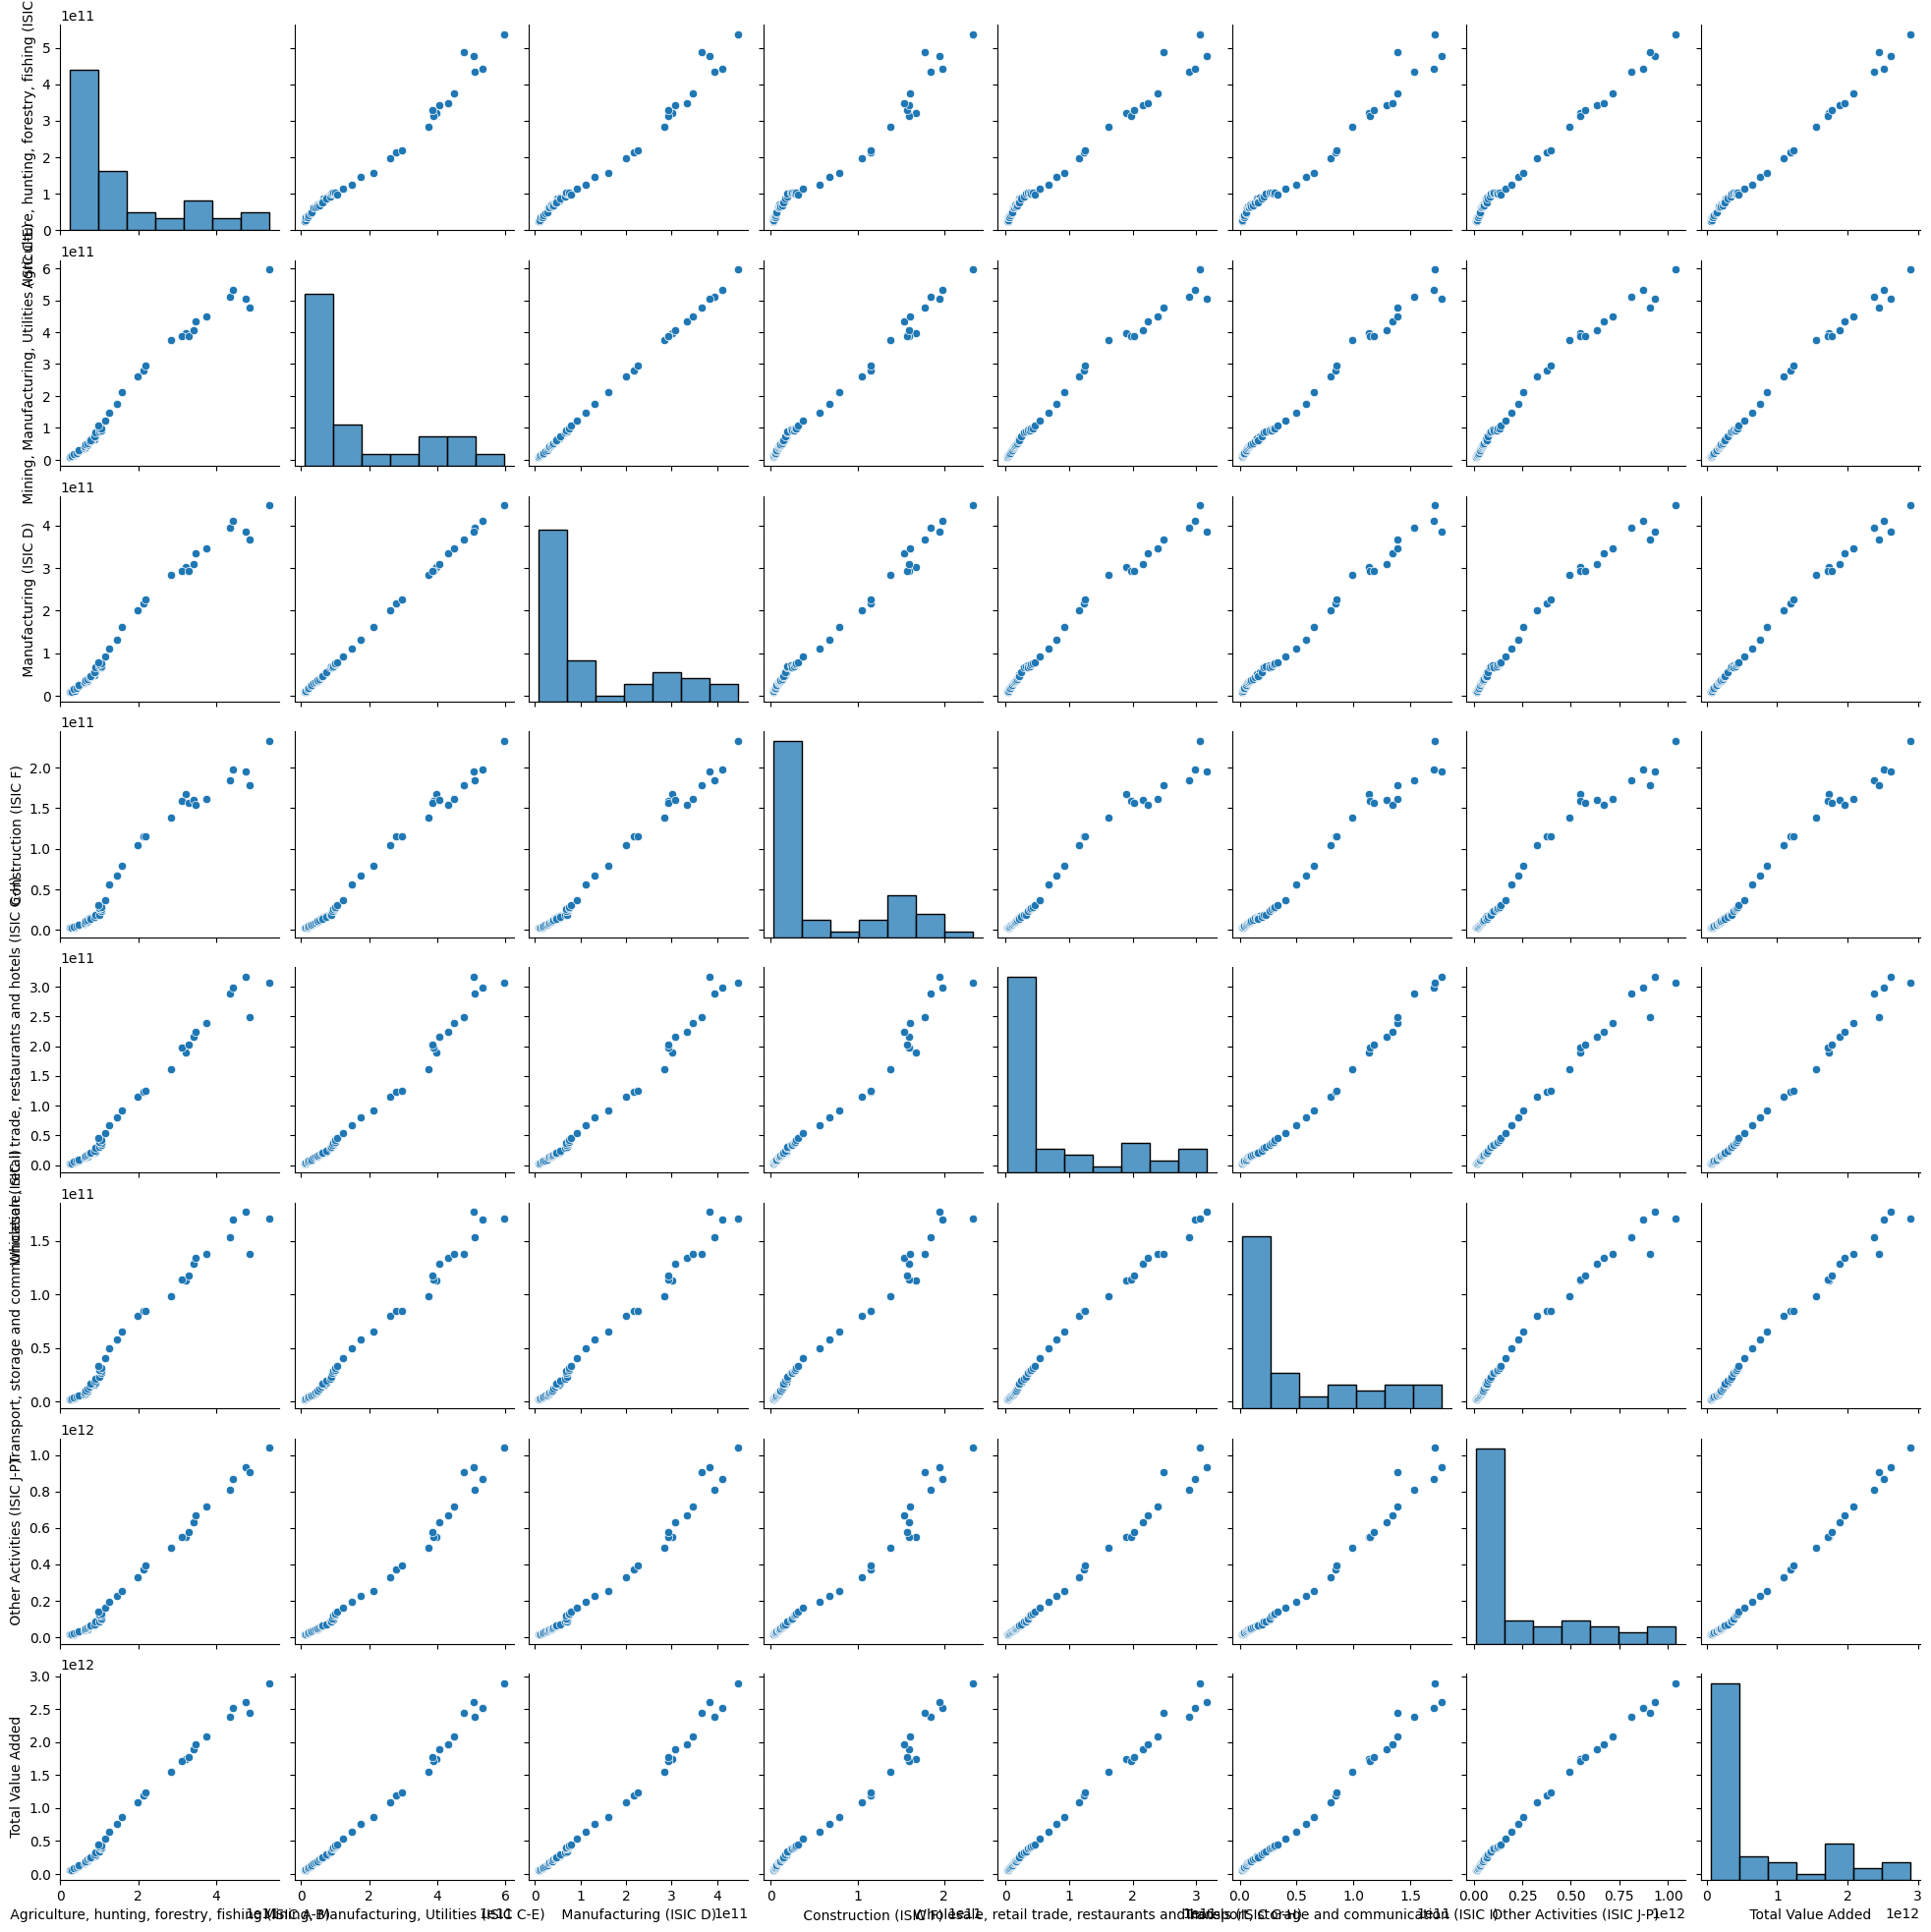

In [13]:
sns.pairplot(df_eco_inde[secteurs_economiques])

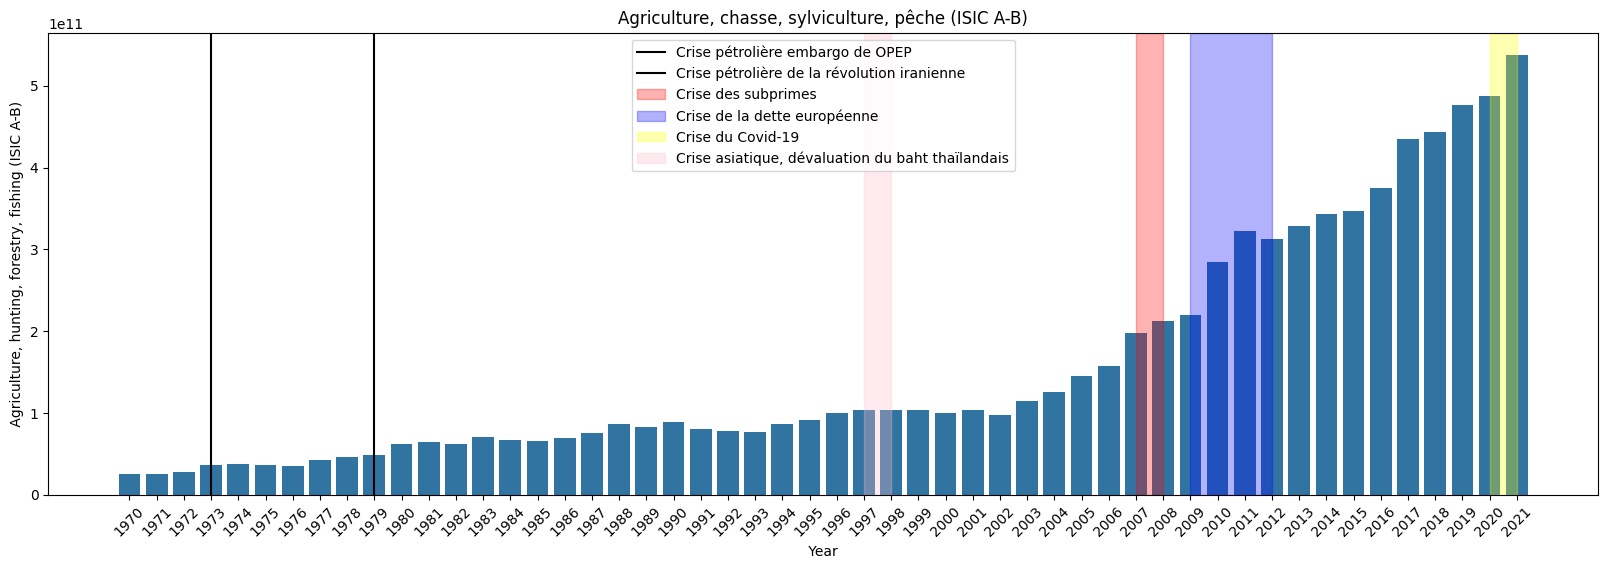

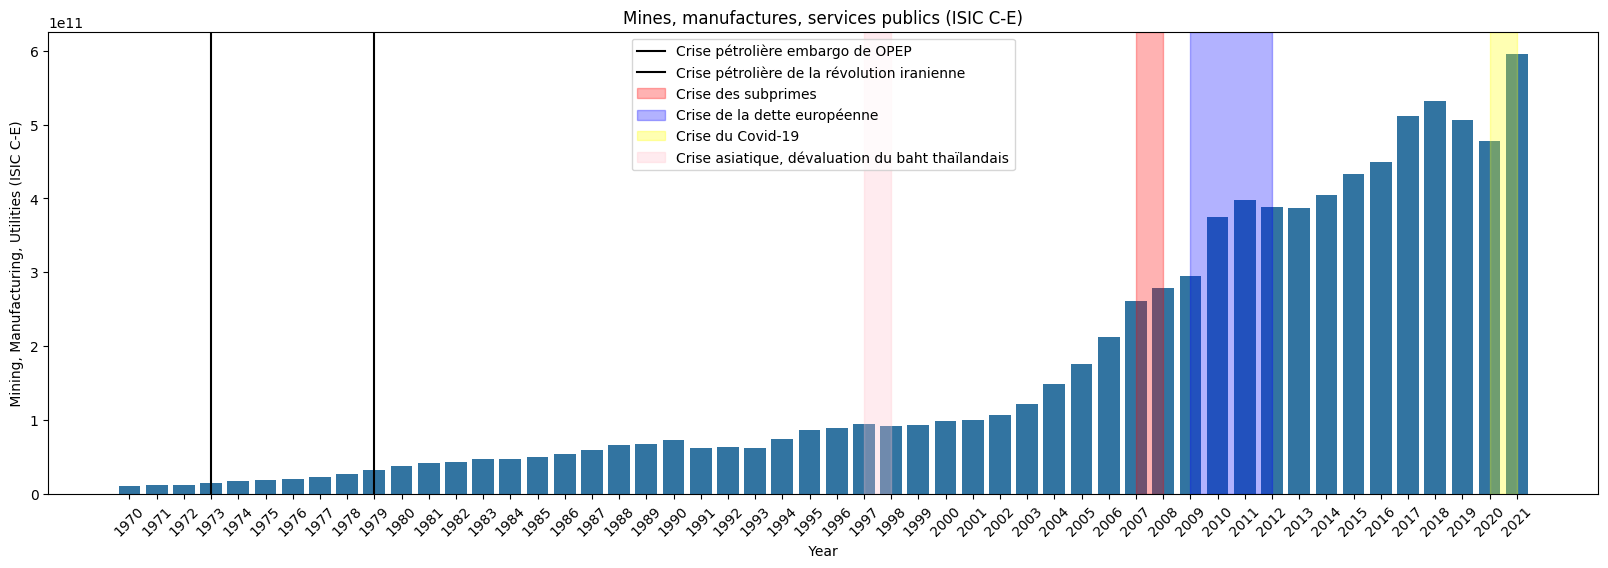

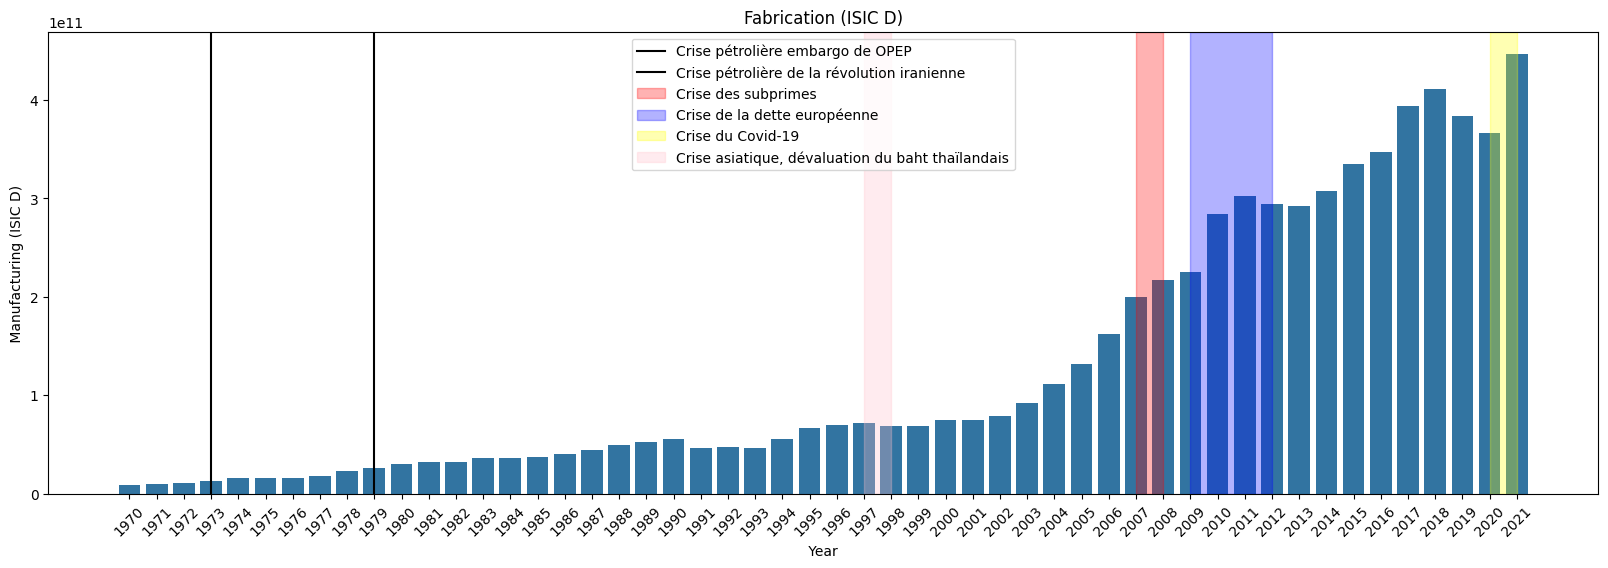

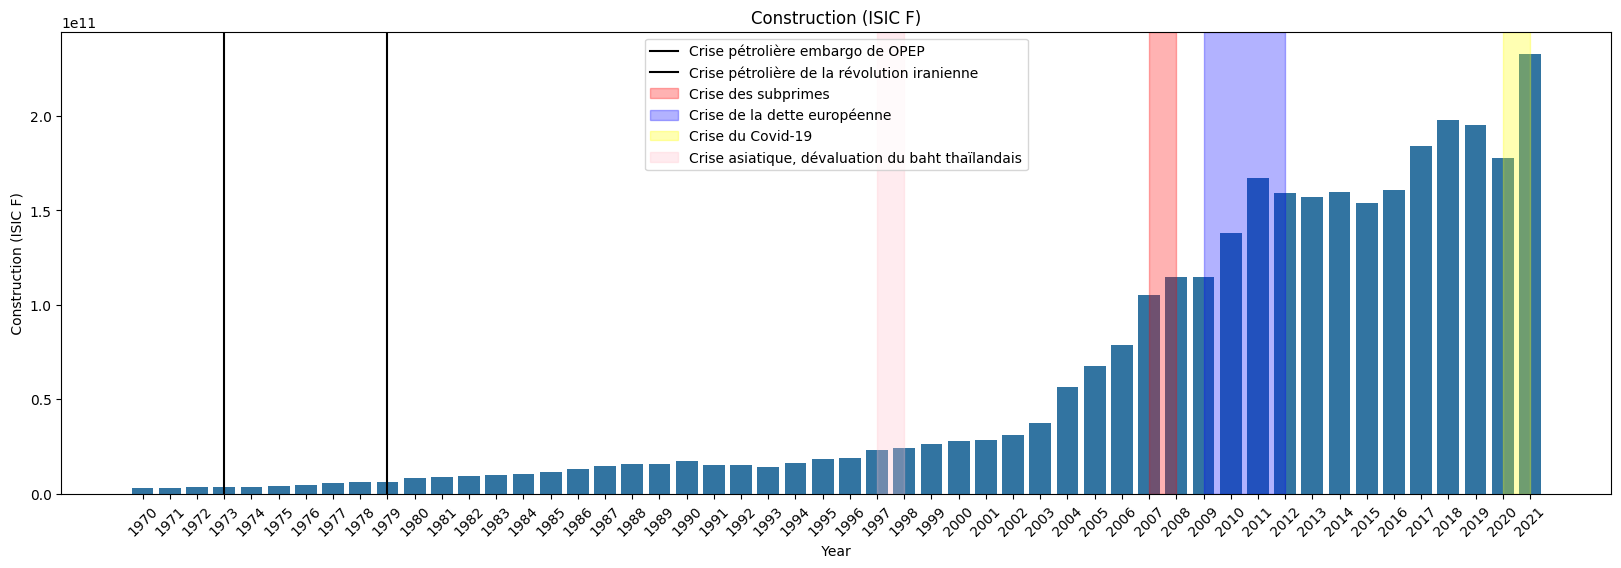

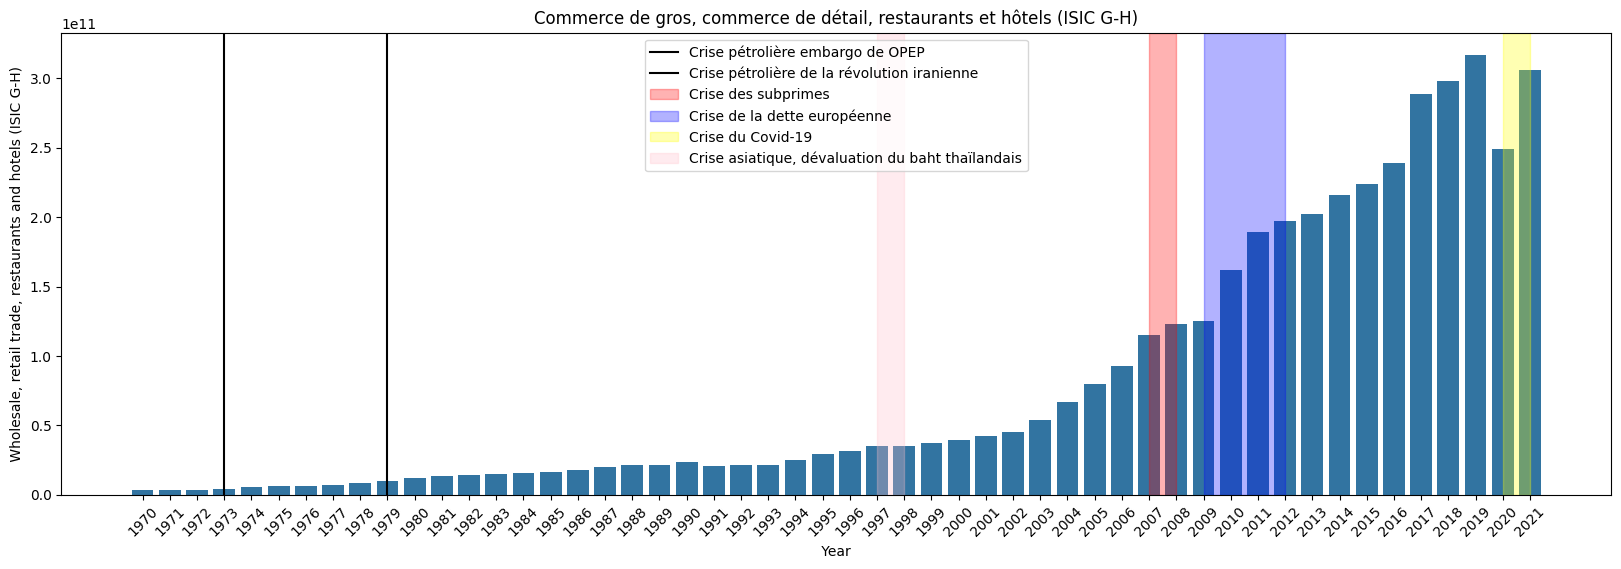

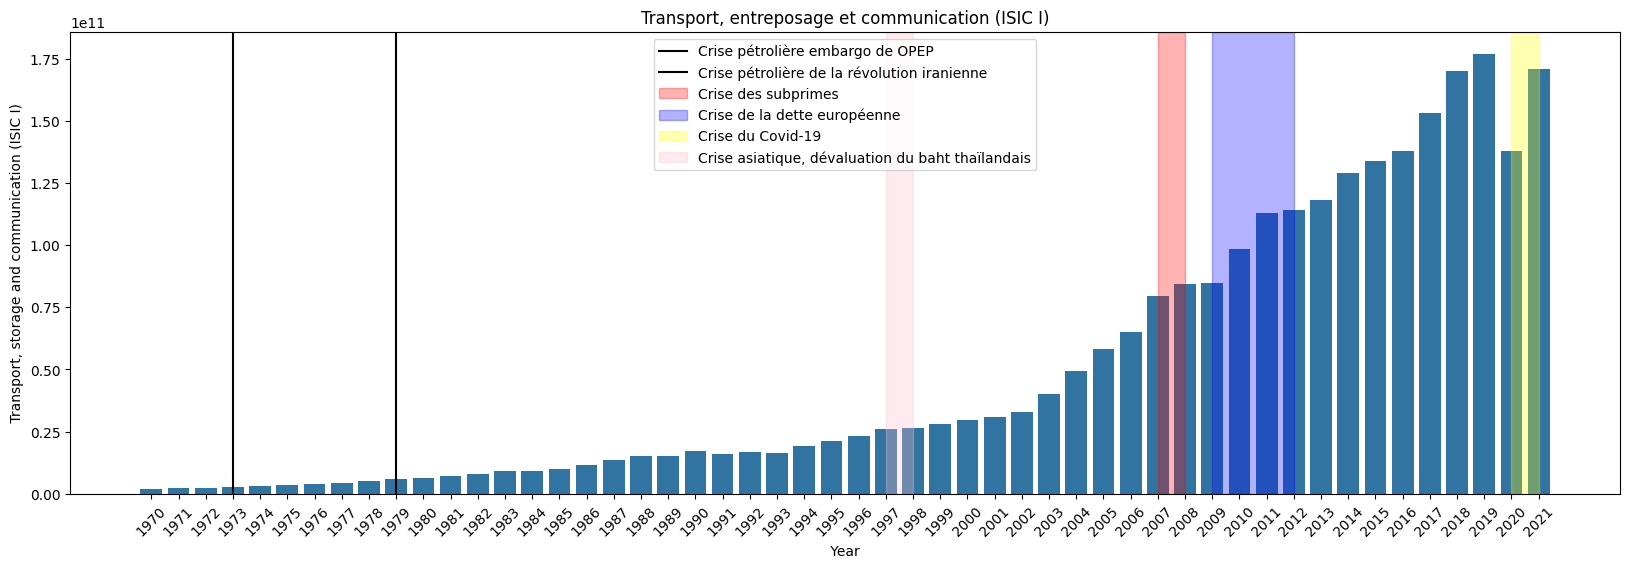

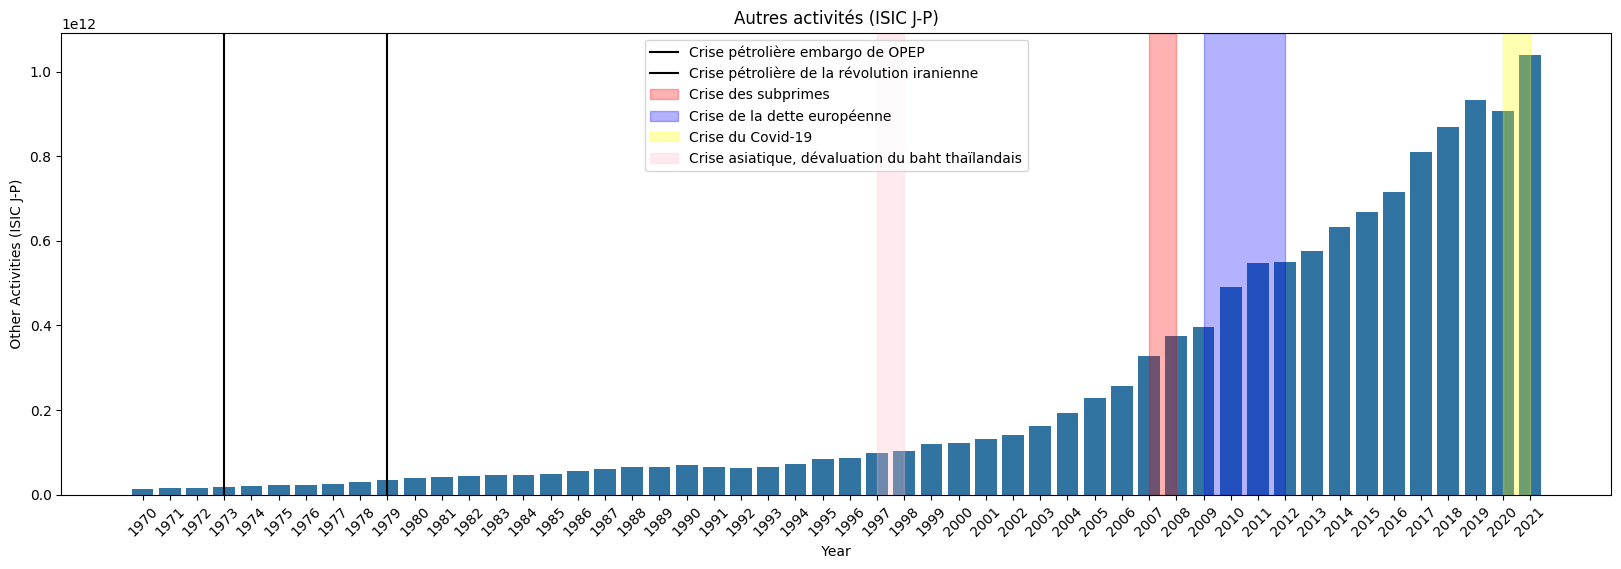

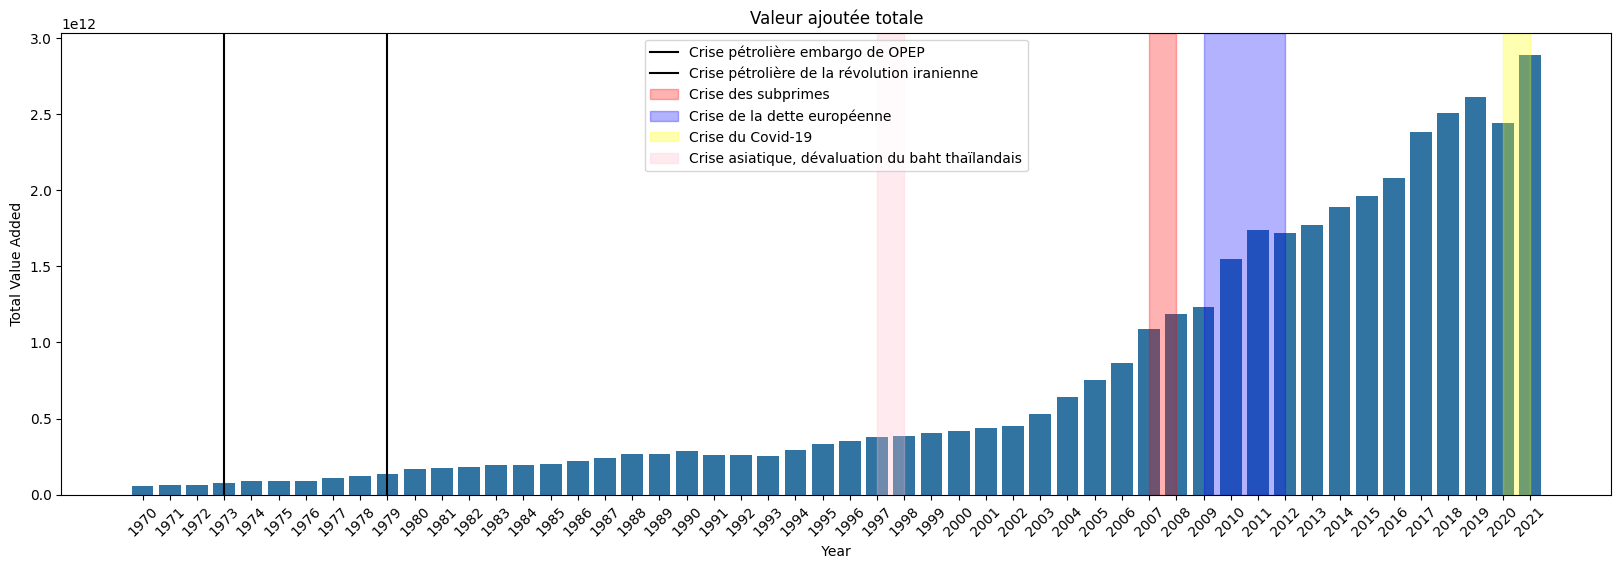

In [29]:
for elem in secteurs_economiques:
    plt.figure(figsize=(20,6))
    sns.barplot(x=df_eco_inde[' Year '], y=df_eco_inde[elem])
    #plt.axvline(x=subprime_d, color='red', linestyle='-', label='début de la Crise des subprimes')
    #plt.axvline(x=subprime_f, color='red', linestyle='-', label='fin de la Crise des subprimes')
    plt.axvline(x=petrole_OPEP, color='black', linestyle='-', label='Crise pétrolière embargo de OPEP')
    plt.axvline(x=petrole_iran, color='black', linestyle='-', label='Crise pétrolière de la révolution iranienne')
    plt.axvspan(subprime_d, subprime_f, color='red',alpha=0.3,  label='Crise des subprimes')
    plt.axvspan(dette_européenne_d, dette_européenne_f, color='blue', alpha=0.3, label='Crise de la dette européenne')
    plt.axvspan(covid_d, covid_f, color='yellow', alpha=0.3, label='Crise du Covid-19')
    plt.axvspan(asiatic_crisis_d, asiatic_crisis_f, color='pink', alpha=0.3, label='Crise asiatique, dévaluation du baht thaïlandais')

    titre=traduction.get(elem, elem)
    plt.title(f'{titre}')
    plt.xticks(rotation=45)
    plt.legend()

plt.show()

### Recherche de corrélation 

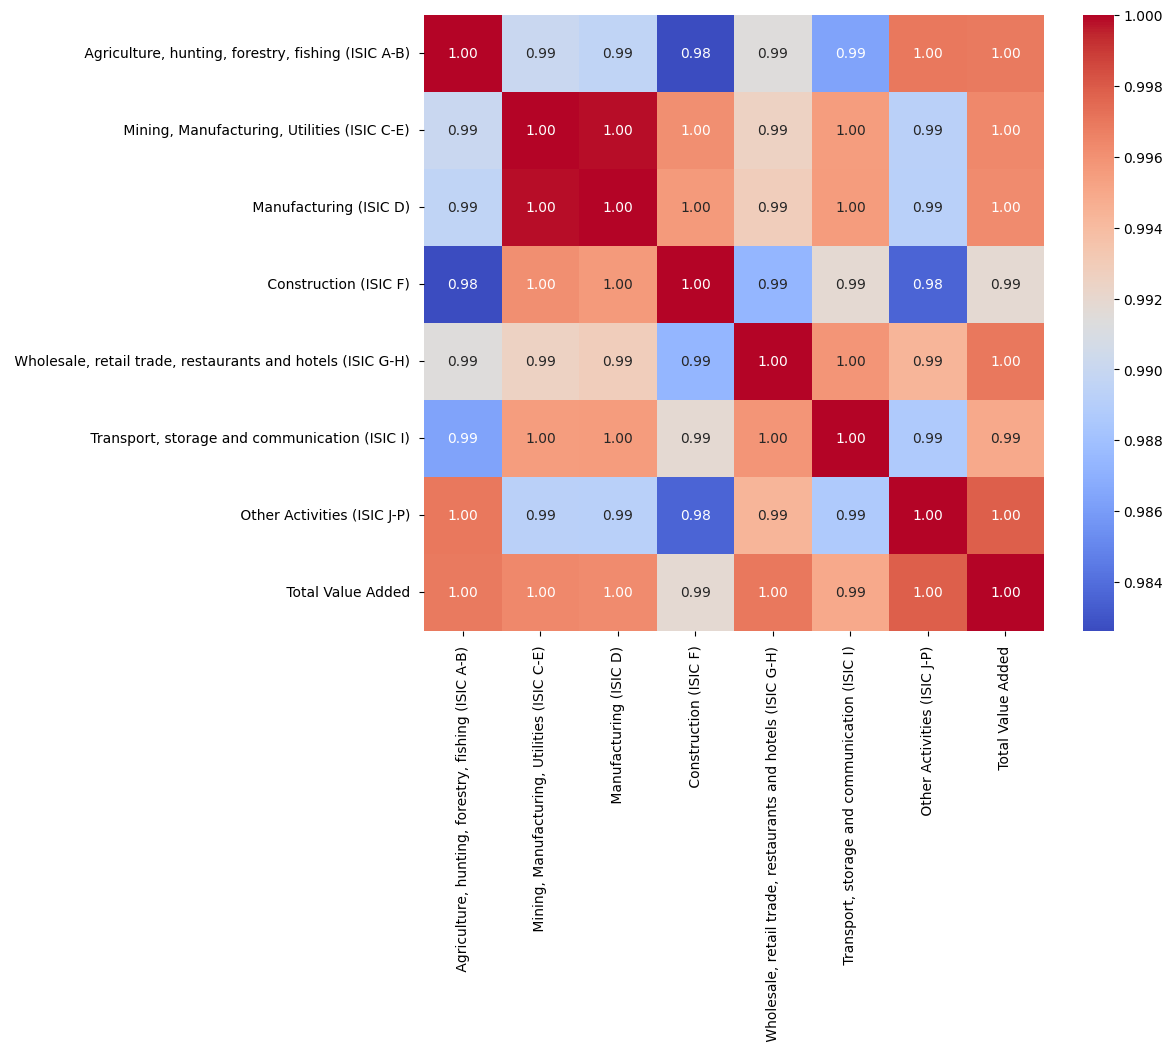

In [23]:
corr_sececo_inde= df_eco_inde[secteurs_economiques]

matrice_sececo_inde=corr_sececo_inde.corr()

plt.figure(figsize=(10,8))
sns.heatmap(matrice_sececo_inde, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()